# **Prediksi Kecelakaan Kerja — PT Besli Manufacturing**

PT Besli Manufacturing mengalami beberapa insiden kecelakaan kerja dalam beberapa tahun terakhir. Untuk mencegah kecelakaan lebih lanjut dan menjaga keselamatan karyawan, tim HR dan keselamatan Besli ingin mengembangkan **sistem prediktif berbasis data historis**.

Dengan menggunakan data karyawan yang mencakup usia, jam kerja, pengalaman kerja, pelatihan K3, shift, jabatan, dan lokasi kerja, perusahaan ingin memprediksi apakah seorang karyawan **berisiko mengalami kecelakaan kerja**.

---
**Target:** `Kecelakaan` (0 = Tidak Kecelakaan, 1 = Kecelakaan)

**Model:** Naive Bayes (Gaussian Naive Bayes)

---
## 1. Preparation

Memanggil seluruh library yang akan digunakan dalam project ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
sns.set_style('whitegrid')
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## 2. Load Dataset

In [2]:
df = pd.read_csv('dataset_kecelakaan.csv')
df.head(10)

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0
5,6,58,49,17,Tidak,Siang,Manager,Gudang,0
6,7,38,46,13,Tidak,Siang,Operator,Gudang,0
7,8,42,38,20,Tidak,Siang,Operator,Quality_Control,1
8,9,65,45,25,Ya,Siang,Operator,Gudang,0
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,0


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Umum Dataset

In [3]:
print('=== Informasi Dataset ===')
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print()
df.info()

=== Informasi Dataset ===
Jumlah baris   : 300
Jumlah kolom   : 9

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    300 non-null    int64 
 1   Usia                  300 non-null    int64 
 2   Jam_Kerja_per_Minggu  300 non-null    int64 
 3   Pengalaman_Tahun      300 non-null    int64 
 4   Pelatihan_K3          300 non-null    object
 5   Shift                 300 non-null    object
 6   Jabatan               300 non-null    object
 7   Lokasi                300 non-null    object
 8   Kecelakaan            300 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 21.2+ KB


In [4]:
df.describe()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.376667,44.780000,17.746667,0.280000
std,86.746758,12.115448,6.597729,10.926747,0.449749
min,1.000000,15.000000,10.000000,1.000000,0.000000
25%,75.750000,30.000000,41.000000,8.000000,0.000000
50%,150.500000,42.000000,45.000000,18.000000,0.000000
75%,225.250000,51.000000,48.000000,27.000000,1.000000
max,300.000000,70.000000,100.000000,60.000000,1.000000


In [5]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
ID                      0
Usia                    0
Jam_Kerja_per_Minggu    0
Pengalaman_Tahun        0
Pelatihan_K3            0
Shift                   0
Jabatan                 0
Lokasi                  0
Kecelakaan              0
dtype: int64


### 3.2 Distribusi Target (Kecelakaan)

C:\Users\pc\AppData\Local\Temp\ipykernel_15388\2709083145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Kecelakaan', data=df, palette='RdBu_r')


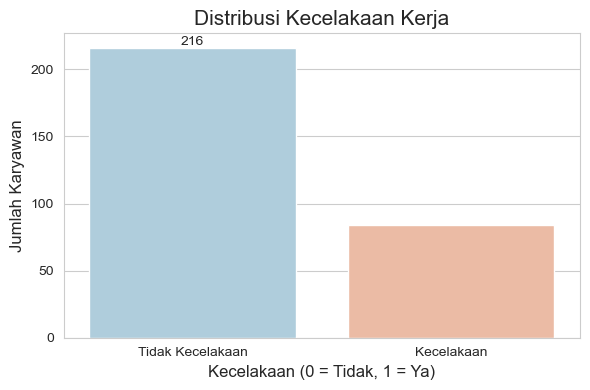

Kecelakaan
0    216
1     84
Name: count, dtype: int64

Persentase kecelakaan: 28.0%


In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Kecelakaan', data=df, palette='RdBu_r')
ax.bar_label(ax.containers[0])
plt.title('Distribusi Kecelakaan Kerja', fontsize=15)
plt.xlabel('Kecelakaan (0 = Tidak, 1 = Ya)', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.xticks([0, 1], ['Tidak Kecelakaan', 'Kecelakaan'])
plt.tight_layout()
plt.show()

print(df['Kecelakaan'].value_counts())
print(f'\nPersentase kecelakaan: {df["Kecelakaan"].mean()*100:.1f}%')

### 3.3 Kecelakaan berdasarkan Fitur Kategorikal

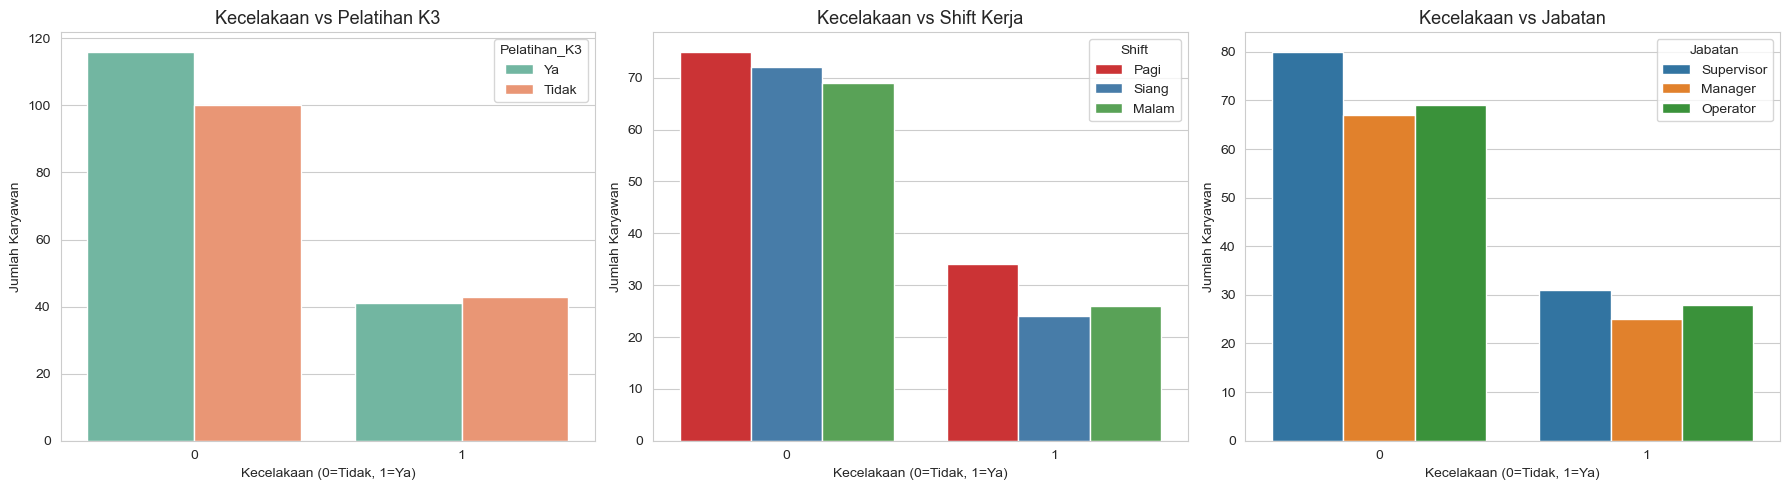

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kecelakaan vs Pelatihan K3
sns.countplot(x='Kecelakaan', hue='Pelatihan_K3', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Kecelakaan vs Pelatihan K3', fontsize=13)
axes[0].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah Karyawan')

# Kecelakaan vs Shift
sns.countplot(x='Kecelakaan', hue='Shift', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Kecelakaan vs Shift Kerja', fontsize=13)
axes[1].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')
axes[1].set_ylabel('Jumlah Karyawan')

# Kecelakaan vs Jabatan
sns.countplot(x='Kecelakaan', hue='Jabatan', data=df, palette='tab10', ax=axes[2])
axes[2].set_title('Kecelakaan vs Jabatan', fontsize=13)
axes[2].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')
axes[2].set_ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_15388\1968709472.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lokasi', y='Persentase_Kecelakaan', data=lokasi_acc_df, palette='Oranges_r')


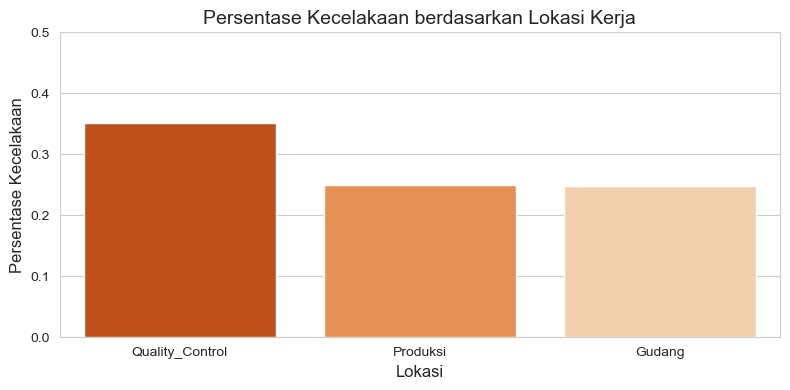

In [8]:
# Persentase kecelakaan per Lokasi
lokasi_acc = df.groupby('Lokasi')['Kecelakaan'].mean().sort_values(ascending=False)
lokasi_acc_df = pd.DataFrame(lokasi_acc).reset_index()
lokasi_acc_df.columns = ['Lokasi', 'Persentase_Kecelakaan']

plt.figure(figsize=(8, 4))
sns.barplot(x='Lokasi', y='Persentase_Kecelakaan', data=lokasi_acc_df, palette='Oranges_r')
plt.title('Persentase Kecelakaan berdasarkan Lokasi Kerja', fontsize=14)
plt.ylabel('Persentase Kecelakaan', fontsize=12)
plt.xlabel('Lokasi', fontsize=12)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

### 3.4 Distribusi Fitur Numerik

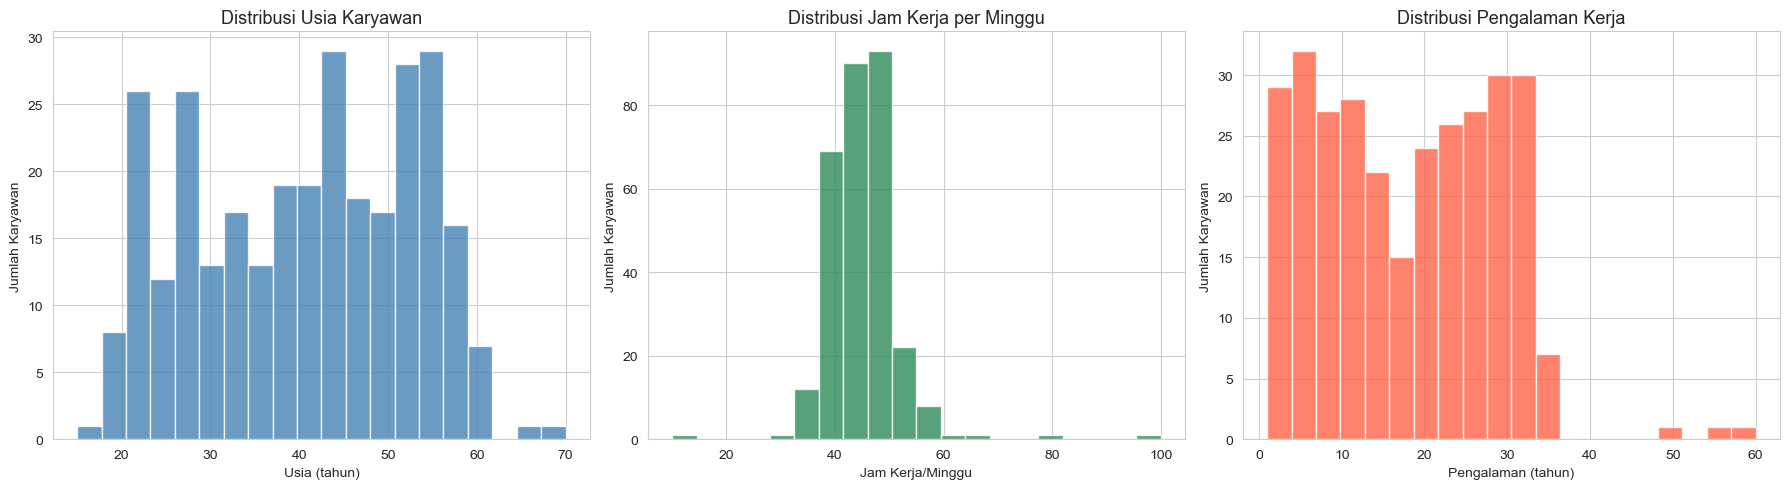

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Usia'].hist(bins=20, color='steelblue', alpha=0.8, ax=axes[0])
axes[0].set_title('Distribusi Usia Karyawan', fontsize=13)
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Jumlah Karyawan')

df['Jam_Kerja_per_Minggu'].hist(bins=20, color='seagreen', alpha=0.8, ax=axes[1])
axes[1].set_title('Distribusi Jam Kerja per Minggu', fontsize=13)
axes[1].set_xlabel('Jam Kerja/Minggu')
axes[1].set_ylabel('Jumlah Karyawan')

df['Pengalaman_Tahun'].hist(bins=20, color='tomato', alpha=0.8, ax=axes[2])
axes[2].set_title('Distribusi Pengalaman Kerja', fontsize=13)
axes[2].set_xlabel('Pengalaman (tahun)')
axes[2].set_ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_15388\3471063553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kecelakaan', y='Usia', data=df, palette='Set2', ax=axes[0])
C:\Users\pc\AppData\Local\Temp\ipykernel_15388\3471063553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kecelakaan', y='Jam_Kerja_per_Minggu', data=df, palette='Set1', ax=axes[1])
C:\Users\pc\AppData\Local\Temp\ipykernel_15388\3471063553.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kecelakaan', y='Pengalaman_Tahun', data=df, palette='Paired', ax=axes[2

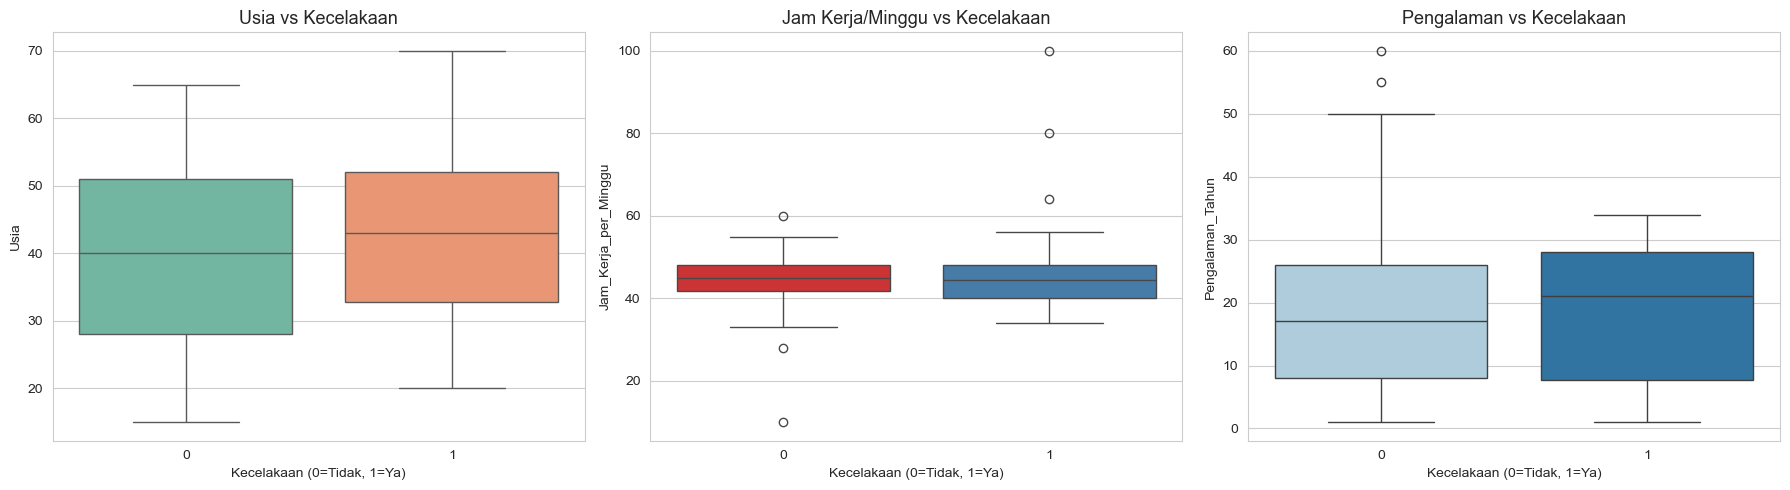

In [10]:
# Boxplot fitur numerik vs Kecelakaan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Kecelakaan', y='Usia', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Usia vs Kecelakaan', fontsize=13)
axes[0].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')

sns.boxplot(x='Kecelakaan', y='Jam_Kerja_per_Minggu', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Jam Kerja/Minggu vs Kecelakaan', fontsize=13)
axes[1].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')

sns.boxplot(x='Kecelakaan', y='Pengalaman_Tahun', data=df, palette='Paired', ax=axes[2])
axes[2].set_title('Pengalaman vs Kecelakaan', fontsize=13)
axes[2].set_xlabel('Kecelakaan (0=Tidak, 1=Ya)')

plt.tight_layout()
plt.show()

### 3.5 Korelasi Antar Fitur Numerik

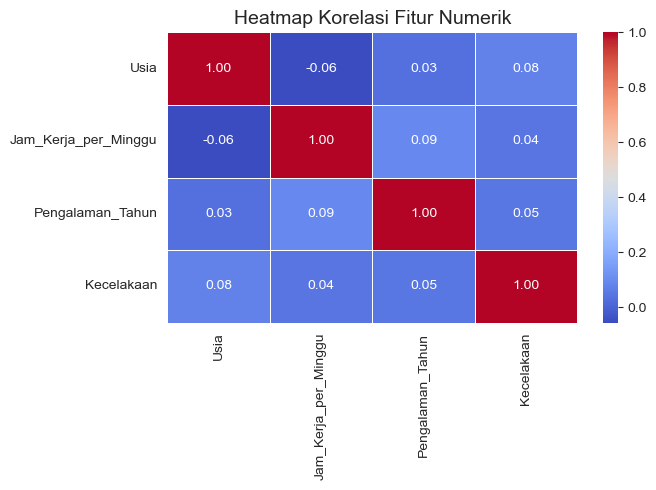

In [11]:
numeric_cols = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Kecelakaan']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

### 4.1 Drop Kolom yang Tidak Diperlukan

In [12]:
# Drop kolom ID karena hanya sebagai identifier, bukan fitur prediktif
df.drop('ID', axis=1, inplace=True)
print('Kolom ID berhasil dihapus.')
print('Kolom yang tersisa:', list(df.columns))

Kolom ID berhasil dihapus.
Kolom yang tersisa: ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan']


### 4.2 Encoding Fitur Kategorikal

Mengubah variabel kategorikal menjadi numerik menggunakan `LabelEncoder`.

In [13]:
le = LabelEncoder()
kategorikal_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

for col in kategorikal_cols:
    df[col] = le.fit_transform(df[col])
    print(f'Kolom "{col}" berhasil di-encode.')

print()
df.head()

Kolom "Pelatihan_K3" berhasil di-encode.
Kolom "Shift" berhasil di-encode.
Kolom "Jabatan" berhasil di-encode.
Kolom "Lokasi" berhasil di-encode.



,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,58,47,10,1,1,2,0,0
1,48,44,17,0,2,2,0,0
2,34,40,22,1,1,0,0,0
3,27,37,26,0,0,0,0,0
4,40,42,25,0,1,2,0,0


In [14]:
print('Tipe data setelah encoding:')
print(df.dtypes)

Tipe data setelah encoding:
Usia                    int64
Jam_Kerja_per_Minggu    int64
Pengalaman_Tahun        int64
Pelatihan_K3            int64
Shift                   int64
Jabatan                 int64
Lokasi                  int64
Kecelakaan              int64
dtype: object


---
## 5. Training

### 5.1 Split Data (Train & Test)

In [15]:
X = df.drop('Kecelakaan', axis=1)
y = df['Kecelakaan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Total data     : {df.shape[0]} baris')
print(f'Data Training  : {X_train.shape[0]} baris (70%)')
print(f'Data Testing   : {X_test.shape[0]} baris (30%)')
print(f'Jumlah fitur   : {X_train.shape[1]} kolom')

Total data     : 300 baris
Data Training  : 210 baris (70%)
Data Testing   : 90 baris (30%)
Jumlah fitur   : 7 kolom


### 5.2 Naive Bayes (Gaussian Naive Bayes)

**Naive Bayes** adalah algoritma klasifikasi berbasis Teorema Bayes dengan asumsi bahwa setiap fitur bersifat **independen satu sama lain** ("naif"). Gaussian Naive Bayes digunakan karena fitur-fitur kita bersifat numerik dan diasumsikan mengikuti distribusi Gaussian (normal).

$$P(y | X) = \frac{P(X | y) \cdot P(y)}{P(X)}$$

In [16]:
# Inisialisasi dan latih model Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

print('Model Gaussian Naive Bayes berhasil dilatih!')
print(f'Jumlah kelas          : {nb.classes_}')
print(f'Prior P(Tidak Kecel.) : {nb.class_prior_[0]:.4f}')
print(f'Prior P(Kecelakaan)   : {nb.class_prior_[1]:.4f}')

Model Gaussian Naive Bayes berhasil dilatih!
Jumlah kelas          : [0 1]
Prior P(Tidak Kecel.) : 0.7190
Prior P(Kecelakaan)   : 0.2810


In [17]:
# Prediksi data uji
y_pred_nb = nb.predict(X_test)
print('Prediksi selesai dilakukan!')

Prediksi selesai dilakukan!


---
## 6. Evaluation

### 6.1 Akurasi, Confusion Matrix, dan Classification Report

In [18]:
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f} ({accuracy*100:.1f}%)')
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Tidak Kecelakaan', 'Kecelakaan']))

Akurasi Model Naive Bayes: 0.67 (66.7%)

Confusion Matrix:
[[60  5]
 [25  0]]

Classification Report:
                  precision    recall  f1-score   support

Tidak Kecelakaan       0.71      0.92      0.80        65
      Kecelakaan       0.00      0.00      0.00        25

        accuracy                           0.67        90
       macro avg       0.35      0.46      0.40        90
    weighted avg       0.51      0.67      0.58        90



<Figure size 600x500 with 0 Axes>

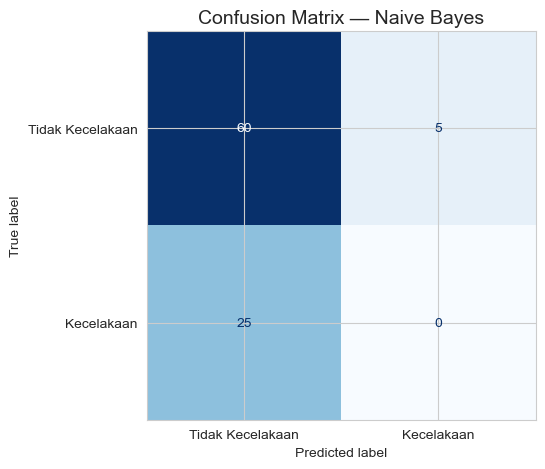

In [19]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Kecelakaan', 'Kecelakaan'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Naive Bayes', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Distribusi Probabilitas Prediksi

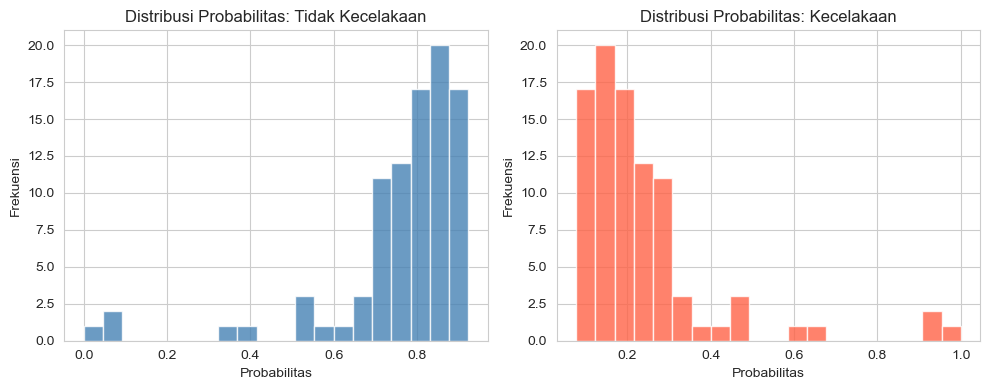

In [20]:
# Probabilitas prediksi untuk setiap sampel test
y_proba = nb.predict_proba(X_test)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_proba[:, 0], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
plt.title('Distribusi Probabilitas: Tidak Kecelakaan', fontsize=12)
plt.xlabel('Probabilitas')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
plt.hist(y_proba[:, 1], bins=20, color='tomato', alpha=0.8, edgecolor='white')
plt.title('Distribusi Probabilitas: Kecelakaan', fontsize=12)
plt.xlabel('Probabilitas')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### 6.3 Distribusi Gaussian per Fitur (Prior Naive Bayes)

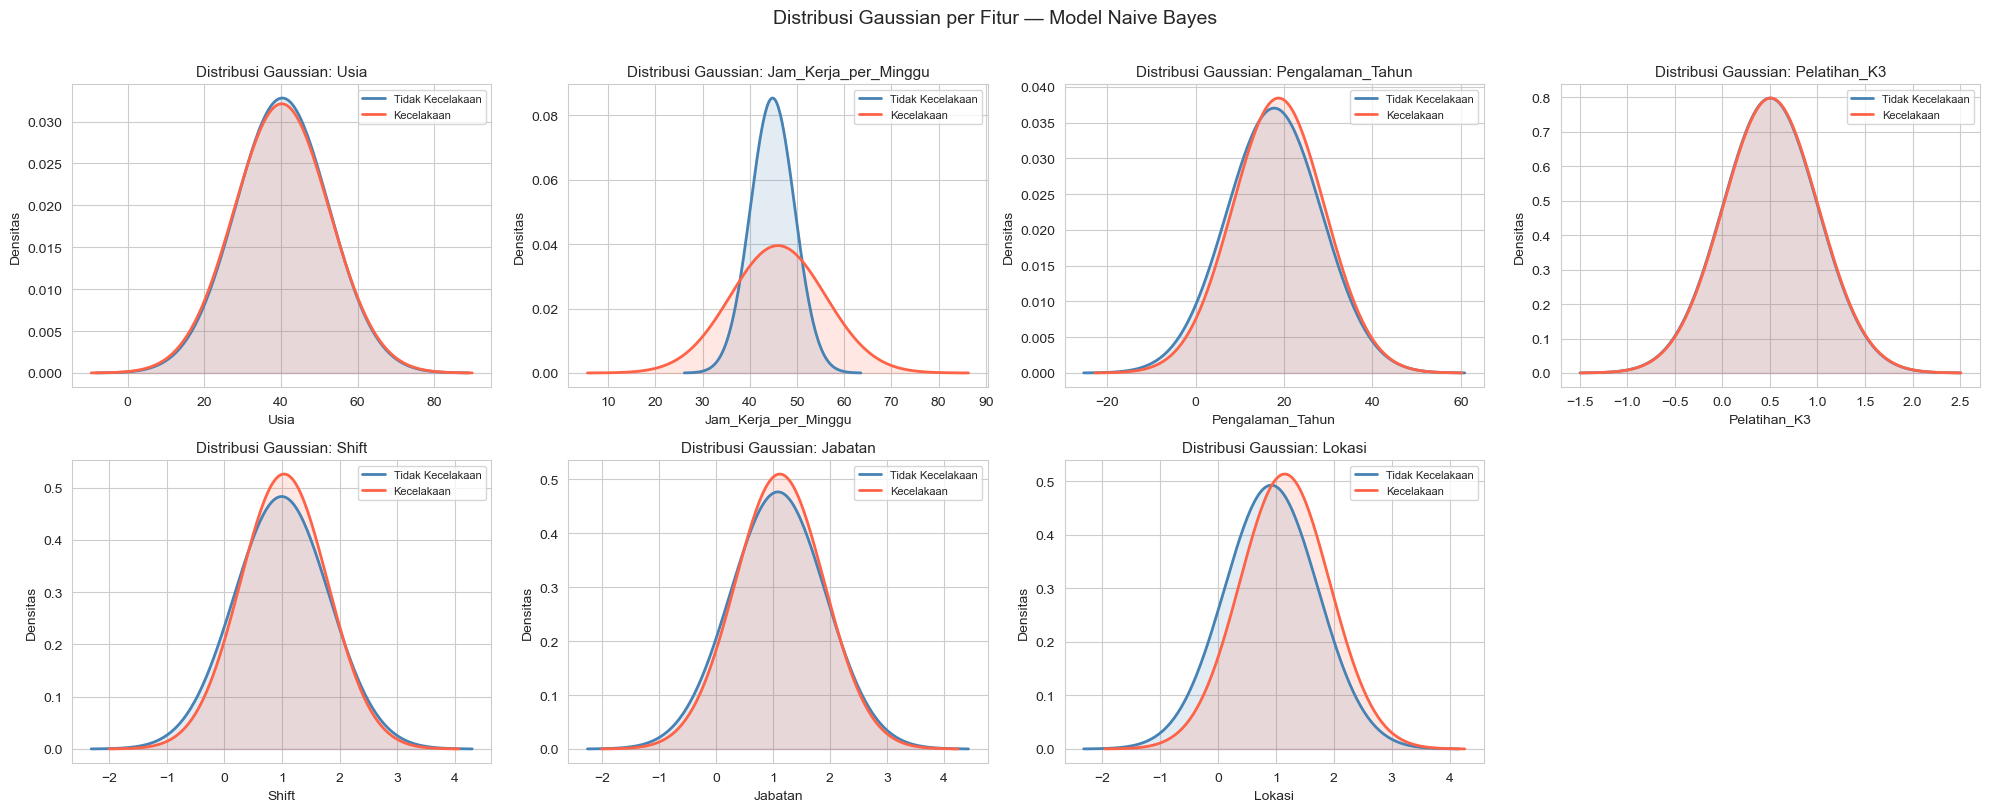

In [21]:
from scipy.stats import norm

feature_names = X.columns.tolist()
means = nb.theta_       # mean per kelas per fitur
variances = nb.var_     # variance per kelas per fitur

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
colors = ['steelblue', 'tomato']
labels = ['Tidak Kecelakaan', 'Kecelakaan']

for i, feat in enumerate(feature_names):
    ax = axes[i]
    for cls in range(2):
        mu = means[cls, i]
        sigma = np.sqrt(variances[cls, i])
        x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
        y_range = norm.pdf(x_range, mu, sigma)
        ax.plot(x_range, y_range, color=colors[cls], label=labels[cls], linewidth=2)
        ax.fill_between(x_range, y_range, alpha=0.15, color=colors[cls])
    ax.set_title(f'Distribusi Gaussian: {feat}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)

# Sembunyikan axes sisa jika ada
for j in range(len(feature_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Gaussian per Fitur — Model Naive Bayes', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Prediksi Data Karyawan Baru

Setelah model berhasil dilatih, kita akan mencoba memprediksi risiko kecelakaan untuk beberapa karyawan baru.

In [22]:
# Cek mapping encoding
df_orig = pd.read_csv('dataset_kecelakaan.csv')
print('=== Mapping Encoding ===')
for col in kategorikal_cols:
    classes = sorted(df_orig[col].unique())
    mapping = {val: idx for idx, val in enumerate(classes)}
    print(f'{col}: {mapping}')

=== Mapping Encoding ===
Pelatihan_K3: {'Tidak': 0, 'Ya': 1}
Shift: {'Malam': 0, 'Pagi': 1, 'Siang': 2}
Jabatan: {'Manager': 0, 'Operator': 1, 'Supervisor': 2}
Lokasi: {'Gudang': 0, 'Produksi': 1, 'Quality_Control': 2}


In [23]:
# Format data baru:
# [Usia, Jam_Kerja_per_Minggu, Pengalaman_Tahun, Pelatihan_K3, Shift, Jabatan, Lokasi]

# Karyawan A: Usia 25, 50 jam/minggu, 2 th pengalaman, tanpa pelatihan K3, shift malam, operator, gudang
# Karyawan B: Usia 45, 40 jam/minggu, 20 th pengalaman, dengan pelatihan K3, shift pagi, supervisor, quality control
# Karyawan C: Usia 35, 48 jam/minggu, 5 th pengalaman, tanpa pelatihan K3, shift siang, operator, gudang

new_data = np.array([
    [25, 50, 2,  0, 0, 1, 0],   # Karyawan A
    [45, 40, 20, 1, 1, 2, 1],   # Karyawan B
    [35, 48, 5,  0, 2, 1, 0],   # Karyawan C
])

label_map = {0: 'Tidak Berisiko', 1: 'BERISIKO KECELAKAAN'}
new_pred = nb.predict(new_data)
new_proba = nb.predict_proba(new_data)

print('=== Hasil Prediksi Karyawan Baru ===')
print()
for i, (pred, proba) in enumerate(zip(new_pred, new_proba)):
    print(f'Karyawan {chr(65+i)}:')
    print(f'  Prediksi                  : {label_map[pred]}')
    print(f'  Prob. Tidak Kecelakaan    : {proba[0]*100:.1f}%')
    print(f'  Prob. Kecelakaan          : {proba[1]*100:.1f}%')
    print()

=== Hasil Prediksi Karyawan Baru ===

Karyawan A:
  Prediksi                  : Tidak Berisiko
  Prob. Tidak Kecelakaan    : 86.2%
  Prob. Kecelakaan          : 13.8%

Karyawan B:
  Prediksi                  : Tidak Berisiko
  Prob. Tidak Kecelakaan    : 76.3%
  Prob. Kecelakaan          : 23.7%

Karyawan C:
  Prediksi                  : Tidak Berisiko
  Prob. Tidak Kecelakaan    : 88.0%
  Prob. Kecelakaan          : 12.0%



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


---
## 8. Kesimpulan

Dari hasil analisis dan pemodelan menggunakan **Gaussian Naive Bayes** pada data kecelakaan kerja PT Besli Manufacturing, beberapa hal penting dapat disimpulkan:

1. **Performa Model:** Model Naive Bayes dapat menggeneralisasi pola dari data historis untuk memprediksi risiko kecelakaan. Performa model dapat dilihat dari nilai akurasi, precision, recall, dan F1-score pada classification report.

2. **Keunggulan Naive Bayes:** Model ini cepat dilatih, tidak sensitif terhadap fitur yang tidak relevan, dan memberikan estimasi probabilitas yang berguna untuk memprioritaskan tindakan pencegahan.

3. **Distribusi Gaussian:** Visualisasi distribusi Gaussian per fitur menunjukkan perbedaan karakteristik antara karyawan yang mengalami kecelakaan dan yang tidak, membantu memahami faktor risiko utama.

4. **Rekomendasi untuk PT Besli Manufacturing:**
   - Prioritaskan **Pelatihan K3** terutama bagi karyawan baru dan yang bertugas di shift malam
   - Pantau karyawan dengan **jam kerja tinggi (>45 jam/minggu)** secara lebih ketat
   - Berikan pendampingan lebih intensif bagi karyawan dengan **pengalaman kerja < 5 tahun**
   - Gunakan probabilitas prediksi dari model untuk **memprioritaskan inspeksi keselamatan** secara proaktif

5. **Pengembangan Selanjutnya:** Bandingkan performa Naive Bayes dengan model lain seperti Decision Tree atau Random Forest, dan pertimbangkan hyperparameter tuning serta penanganan class imbalance untuk meningkatkan performa.

## 2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing

feature enginering adalah proses menyiapkan dan mengubah data mentah menjadi bentuk yang lebih bermakna agar model Machine Learning dapat belajar dengan lebih baik dan menghasilkan prediksi yang akurat .peran dari feature engineering dalam pemodelan adalah Membuat Data Bisa Dibaca oleh Model
Algoritma Machine Learning hanya memahami angka, Menghilangkan Noise dan Informasi Tidak Relevan
Tidak semua kolom dalam dataset berkontribusi positif terhadap prediksi,Meningkatkan Performa Model
Fitur yang direpresentasikan dengan baik membantu model menemukan pola lebih cepat dan lebih tepat, sehingga menghasilkan akurasi, precision, dan recall yang lebih tinggi.



### Contoh Feature Engineering dari Studi Kasus PT Besli Manufacturing (Naive Bayes)

 1. Drop Kolom Tidak Relevan — Menghapus Kolom

In [ ]:
df.drop('ID', axis=1, inplace=True)

2. Label Encoding — Mengubah Kategori Menjadi Angka

In [ ]:
le = LabelEncoder()
kategorikal_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

for col in kategorikal_cols:
    df[col] = le.fit_transform(df[col])

## 3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing Jelaskan?

Confusion Matrix adalah tabel ringkasan hasil prediksi model yang membandingkan nilai prediksi dengan nilai aktual. Disebut "confusion" karena tabel ini menunjukkan di mana model "bingung" atau salah mengklasifikasikan data.


### Konteks Studi Kasus PT Besli Manufacturing
Pada notebook Naive Bayes, evaluasi dilakukan pada 90 data testing (30% dari 300 data). Distribusinya mengikuti proporsi asli: sekitar 65 karyawan tidak kecelakaan dan 25 karyawan kecelakaan.

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Tidak Kecelakaan', 'Kecelakaan'])

Confusion matrix yang dihasilkan model membagi 90 prediksi ke dalam 4 kotak:

In [ ]:
PREDIKSI MODEL
                  Tidak Kecel.   Kecelakaan
AKTUAL  Tidak     [    TN      |    FP    ]
        Kecel.    [    FN      |    TP    ]

### 1.  Accuracy (Akurasi)

In [ ]:
Accuracy=TP+TN+FP+FNTP+TN​


In [ ]:
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

Konteks PT Besli: Akurasi memberi gambaran umum seberapa sering model benar. Namun karena data tidak seimbang (72% tidak kecelakaan vs 28% kecelakaan), akurasi tinggi belum tentu berarti model bagus — model bisa saja selalu prediksi "tidak kecelakaan" dan tetap dapat akurasi 72%.

### 2. Precision

In [ ]:
Precision=TP+FPTP​

Artinya: Dari semua yang diprediksi "Kecelakaan", berapa yang benar-benar kecelakaan?
Konteks PT Besli: Precision tinggi artinya ketika model memberikan peringatan risiko, peringatan itu dapat dipercaya. Jika precision rendah, tim HR terlalu sering memanggil karyawan yang sebenarnya aman (banyak FP) — membuang waktu dan sumber daya.

### 3.  Recall (Sensitivity)

In [ ]:
F1-Score=2×Precision+RecallPrecision×Recall​

Artinya: Rata-rata harmonis antara Precision dan Recall — menyeimbangkan keduanya dalam satu angka.
Konteks PT Besli: F1-Score berguna karena data tidak seimbang. Ia merangkum kemampuan model dalam mendeteksi kecelakaan (recall) sekaligus ketepatan peringatannya (precision).

### 4. F1-Score

In [ ]:
F1-Score=2×Precision+RecallPrecision×Recall​

Artinya: Rata-rata harmonis antara Precision dan Recall — menyeimbangkan keduanya dalam satu angka.

Konteks PT Besli: F1-Score berguna karena data tidak seimbang. Ia merangkum kemampuan model dalam mendeteksi kecelakaan (recall) sekaligus ketepatan peringatannya (precision).

### 5. Classification Report (Ringkasan Semua Metrik)

In [26]:
print(classification_report(y_test, y_pred_nb,
      target_names=['Tidak Kecelakaan', 'Kecelakaan']))

                  precision    recall  f1-score   support

Tidak Kecelakaan       0.71      0.92      0.80        65
      Kecelakaan       0.00      0.00      0.00        25

        accuracy                           0.67        90
       macro avg       0.35      0.46      0.40        90
    weighted avg       0.51      0.67      0.58        90



Support = jumlah data aktual per kelas di data testing (65 tidak kecelakaan, 25 kecelakaan).